<a href="https://colab.research.google.com/github/AntonKrokhin/sales-analytics-with-python/blob/main/Exploratary_sales_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Connecting Google Drive
from google.colab import drive
drive.mount("/content/drive")
%cd /content/drive/MyDrive/Mate

# import CSV files
events = pd.read_csv("events.csv")
countries = pd.read_csv("countries.csv")
products = pd.read_csv("products.csv")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Mate


# **1. Data overview**

In [ ]:
# Check data content
print("\nEvents table:\n",events.head())
print("\nCountries table:\n",countries.head())
print("\nProducts table:\n",products.head())


Events table:
     Order ID Order Date   Ship Date Order Priority Country Code  Product ID  \
0  100640618  10/8/2014  10/18/2014              M          NOR        2103   
1  100983083  8/11/2016   8/11/2016              C          SRB        2103   
2  101025998  7/18/2014   8/11/2014              M          NaN        7940   
3  102230632  5/13/2017   6/13/2017              L          MNE        2455   
4  103435266  8/11/2012   9/18/2012              H          SRB        1270   

  Sales Channel  Units Sold  Unit Price  Unit Cost  
0        Online       650.0      205.70     117.11  
1       Offline      1993.0      205.70     117.11  
2        Online      4693.0      668.27     502.54  
3        Online      1171.0      109.28      35.84  
4       Offline      7648.0       47.45      31.79  

Countries table:
              name alpha-2 alpha-3   region       sub-region
0     Afghanistan      AF     AFG     Asia    Southern Asia
1   Åland Islands      AX     ALA   Europe  Northern

In [ ]:
# Check data types
print("\nEvents table:\n")
events.info()
print("\nCountries table:\n")
countries.info()
print("\nProducts table:\n")
products.info()


Events table:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        1330 non-null   int64  
 1   Order Date      1330 non-null   object 
 2   Ship Date       1330 non-null   object 
 3   Order Priority  1330 non-null   object 
 4   Country Code    1248 non-null   object 
 5   Product ID      1330 non-null   int64  
 6   Sales Channel   1330 non-null   object 
 7   Units Sold      1328 non-null   float64
 8   Unit Price      1330 non-null   float64
 9   Unit Cost       1330 non-null   float64
dtypes: float64(3), int64(2), object(5)
memory usage: 104.0+ KB

Countries table:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        249 non-null    object
 1   alpha-2     248 non-null 

***"Events" table:***
*   *Order ID* - order identifier
*   *Order Date* - order date
*   *Ship Date* - shipment date
*   *Order Priority* - H - High, M - Medium, L - Low, C - Critical
*   *Country Code* - 3-letter country code
*   *Product ID* - product identifier
*   *Sales Channel* - sales channel (Online/Offline)
*   *Units Sold* - number of units sold
*   *Unit Price* - price per unit
*   *Unit Cost* - cost per unit


***"Products" table:***
*   *id* - product identifier
*   *item_type* - product category


***"Countries" table:***
*   *name* - country name
*   *alpha-2* - 2-letter country code
*   *alpha-3* - 3-letter country code
*   *region* - region
*   *sub-region* - subregion

In [ ]:
# Descriptive statistics for numerical columns
events.describe()

,Order ID,Product ID,Units Sold,Unit Price,Unit Cost
count,1.330000e+03,1330.000000,1328.000000,1330.000000,1330.000000
mean,5.412048e+08,5788.096241,4952.201807,264.893541,187.246812
std,2.573882e+08,2820.728878,2905.198996,217.323460,176.158873
min,1.006406e+08,1270.000000,2.000000,9.330000,6.920000
25%,3.190004e+08,3127.000000,2356.750000,81.730000,35.840000
50%,5.387164e+08,5988.000000,4962.000000,154.060000,97.440000
75%,7.544628e+08,8681.000000,7459.500000,437.200000,263.330000
max,9.998797e+08,8969.000000,9999.000000,668.270000,524.960000


# **2. Data cleaning**

In [ ]:
# Number of missing values ​​in each column:
print("\nEvents table:\n",events.isna().sum())
print("\nCountries table:\n",countries.isna().sum())
print("\nProducts table:\n",products.isna().sum())


Events table:
 Order ID           0
Order Date         0
Ship Date          0
Order Priority     0
Country Code      82
Product ID         0
Sales Channel      0
Units Sold         2
Unit Price         0
Unit Cost          0
dtype: int64

Countries table:
 name          0
alpha-2       1
alpha-3       0
region        1
sub-region    1
dtype: int64

Products table:
 id           0
item_type    0
dtype: int64


In [ ]:
# Percentage of missing values ​​in each column:
print("\nEvents table:\n",events.isna().sum()/events.shape[0] * 100)
print("\nCountries table:\n",countries.isna().sum()/countries.shape[0] * 100)
print("\nProducts table:\n",products.isna().sum()/products.shape[0] * 100)


Events table:
 Order ID          0.000000
Order Date        0.000000
Ship Date         0.000000
Order Priority    0.000000
Country Code      6.165414
Product ID        0.000000
Sales Channel     0.000000
Units Sold        0.150376
Unit Price        0.000000
Unit Cost         0.000000
dtype: float64

Countries table:
 name          0.000000
alpha-2       0.401606
alpha-3       0.000000
region        0.401606
sub-region    0.401606
dtype: float64

Products table:
 id           0.0
item_type    0.0
dtype: float64


In [ ]:
# Remove rows with missing values in Units Sold
events = events.dropna(subset=['Units Sold'])

# Replace missing values in "Country Code" with "Unknown"
events["Country Code"] = events["Country Code"].fillna("Unknown")

In [ ]:
# Find rows with at least one missing value in the Countries table
missing_values = countries[countries.isna().any(axis=1)]
print(missing_values)

           name alpha-2 alpha-3  region          sub-region
8    Antarctica      AQ     ATA     NaN                 NaN
153     Namibia     NaN     NAM  Africa  Sub-Saharan Africa


In [ ]:
# Fill missing values for Namibia
countries.loc[countries["name"] == "Namibia", "alpha-2"] = "NA"

# Fill missing values for Antarctica
countries["region"] = countries["region"].fillna("Antarctica")
countries["sub-region"] = countries["sub-region"].fillna("Antarctica")

# Check if everything is ok
check_countries = countries[countries["name"].isin(["Namibia", "Antarctica"])]
print(check_countries)

           name alpha-2 alpha-3      region          sub-region
8    Antarctica      AQ     ATA  Antarctica          Antarctica
153     Namibia      NA     NAM      Africa  Sub-Saharan Africa


In [ ]:
# Check again number of missing values ​​in each column
print("\nEvents table:\n",events.isna().sum())
print("\nCountries table:\n",countries.isna().sum())
print("\nProducts table:\n",products.isna().sum())


Events table:
 Order ID          0
Order Date        0
Ship Date         0
Order Priority    0
Country Code      0
Product ID        0
Sales Channel     0
Units Sold        0
Unit Price        0
Unit Cost         0
dtype: int64

Countries table:
 name          0
alpha-2       0
alpha-3       0
region        0
sub-region    0
dtype: int64

Products table:
 id           0
item_type    0
dtype: int64


### Missing values in the "Units Sold" column were dropped because their percentage was minor and had no impact on overall statistics.

### Missing values in the "Country Code" column were replaced with "Unknown" because this column is categorical and does not affect the results of calculations.

### Missing values in the "Country" table were manually verified and corrected.

In [ ]:
# Data type conversion in the columns
events["Order Date"] = pd.to_datetime(events["Order Date"])
events["Ship Date"] = pd.to_datetime(events["Ship Date"])
events["Units Sold"] = events["Units Sold"].astype("int64")

In [ ]:
# Check again data types
print("\nEvents table:\n")
events.info()
print("\nCountries table:\n")
countries.info()
print("\nProducts table:\n")
products.info()


Events table:

<class 'pandas.core.frame.DataFrame'>
Index: 1328 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order ID        1328 non-null   int64         
 1   Order Date      1328 non-null   datetime64[ns]
 2   Ship Date       1328 non-null   datetime64[ns]
 3   Order Priority  1328 non-null   object        
 4   Country Code    1328 non-null   object        
 5   Product ID      1328 non-null   int64         
 6   Sales Channel   1328 non-null   object        
 7   Units Sold      1328 non-null   int64         
 8   Unit Price      1328 non-null   float64       
 9   Unit Cost       1328 non-null   float64       
dtypes: datetime64[ns](2), float64(2), int64(3), object(3)
memory usage: 114.1+ KB

Countries table:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------ 

In [ ]:
# Check for duplicate rows in all tables
print("Events table duplicates:", events.duplicated().sum())
print("Countries table duplicates:", countries.duplicated().sum())
print("Products table duplicates:", products.duplicated().sum())

Events table duplicates: 0
Countries table duplicates: 0
Products table duplicates: 0


# **3. Data analysis and visualization**

In [ ]:
# Merge three tables into one DataFrame
df = events.merge(products, left_on="Product ID", right_on="id", how="left")
df = df.merge(countries, left_on="Country Code", right_on="alpha-3", how="left")
df.head()

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost,id,item_type,name,alpha-2,alpha-3,region,sub-region
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650,205.70,117.11,2103,Cereal,Norway,NO,NOR,Europe,Northern Europe
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,1993,205.70,117.11,2103,Cereal,Serbia,RS,SRB,Europe,Southern Europe
2,101025998,2014-07-18,2014-08-11,M,Unknown,7940,Online,4693,668.27,502.54,7940,Household,NaN,NaN,NaN,NaN,NaN
3,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,1171,109.28,35.84,2455,Clothes,Montenegro,ME,MNE,Europe,Southern Europe
4,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,7648,47.45,31.79,1270,Beverages,Serbia,RS,SRB,Europe,Southern Europe


In [ ]:
# Drop unnecessary columns
df = df.drop(columns=["Product ID", "id", "alpha-2", "alpha-3"])
df.head()

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Sales Channel,Units Sold,Unit Price,Unit Cost,item_type,name,region,sub-region
0,100640618,2014-10-08,2014-10-18,M,NOR,Online,650,205.70,117.11,Cereal,Norway,Europe,Northern Europe
1,100983083,2016-08-11,2016-08-11,C,SRB,Offline,1993,205.70,117.11,Cereal,Serbia,Europe,Southern Europe
2,101025998,2014-07-18,2014-08-11,M,Unknown,Online,4693,668.27,502.54,Household,NaN,NaN,NaN
3,102230632,2017-05-13,2017-06-13,L,MNE,Online,1171,109.28,35.84,Clothes,Montenegro,Europe,Southern Europe
4,103435266,2012-08-11,2012-09-18,H,SRB,Offline,7648,47.45,31.79,Beverages,Serbia,Europe,Southern Europe


In [ ]:
# Rename columns
df = df.rename(columns={"item_type": "product_category", "name": "country"})
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_").str.replace("-", "_")
df.head()

,order_id,order_date,ship_date,order_priority,country_code,sales_channel,units_sold,unit_price,unit_cost,product_category,country,region,sub_region
0,100640618,2014-10-08,2014-10-18,M,NOR,Online,650,205.70,117.11,Cereal,Norway,Europe,Northern Europe
1,100983083,2016-08-11,2016-08-11,C,SRB,Offline,1993,205.70,117.11,Cereal,Serbia,Europe,Southern Europe
2,101025998,2014-07-18,2014-08-11,M,Unknown,Online,4693,668.27,502.54,Household,NaN,NaN,NaN
3,102230632,2017-05-13,2017-06-13,L,MNE,Online,1171,109.28,35.84,Clothes,Montenegro,Europe,Southern Europe
4,103435266,2012-08-11,2012-09-18,H,SRB,Offline,7648,47.45,31.79,Beverages,Serbia,Europe,Southern Europe


In [ ]:
# Fill the voids that arose after connecting to unknown countries
df["country"] = df["country"].fillna("Unknown")
df["region"] = df["region"].fillna("Unknown")
df["sub_region"] = df["sub_region"].fillna("Unknown")
df.head()

,order_id,order_date,ship_date,order_priority,country_code,sales_channel,units_sold,unit_price,unit_cost,product_category,country,region,sub_region
0,100640618,2014-10-08,2014-10-18,M,NOR,Online,650,205.70,117.11,Cereal,Norway,Europe,Northern Europe
1,100983083,2016-08-11,2016-08-11,C,SRB,Offline,1993,205.70,117.11,Cereal,Serbia,Europe,Southern Europe
2,101025998,2014-07-18,2014-08-11,M,Unknown,Online,4693,668.27,502.54,Household,Unknown,Unknown,Unknown
3,102230632,2017-05-13,2017-06-13,L,MNE,Online,1171,109.28,35.84,Clothes,Montenegro,Europe,Southern Europe
4,103435266,2012-08-11,2012-09-18,H,SRB,Offline,7648,47.45,31.79,Beverages,Serbia,Europe,Southern Europe


### **Key performance indicators**

In [ ]:
# Total orders
orders_cnt = df["order_id"].count()
print("Total number of orders:", orders_cnt)

Total number of orders: 1328


In [ ]:
# Total product categories
category_cnt = df["product_category"].nunique()
print("Total number of category:", category_cnt)

Total number of category: 12


In [ ]:
# Total countries
country_cnt = df["country"].nunique()
print("Total number of country:", country_cnt)

Total number of country: 46


In [ ]:
# Total units sold by product category
units_sold_by_category = df.groupby("product_category")["units_sold"].sum().sort_values(ascending=False).reset_index()
print(units_sold_by_category)

   product_category  units_sold
0   Office Supplies      617641
1         Beverages      613133
2            Fruits      591672
3           Clothes      591385
4        Vegetables      582544
5         Baby Food      562706
6     Personal Care      557678
7         Cosmetics      533291
8              Meat      530380
9            Snacks      490160
10           Cereal      465685
11        Household      440249


In [ ]:
# Total units sold by country
units_sold_by_country = df.groupby("country")["units_sold"].sum().sort_values(ascending=False).reset_index()
print(units_sold_by_country)

                   country  units_sold
0                  Unknown      404853
1                Macedonia      203078
2               San Marino      192228
3                  Andorra      185686
4                   Greece      176859
5                    Malta      173641
6                   Serbia      170369
7                  Romania      166882
8                   Russia      165954
9                  Ukraine      164577
10                  Cyprus      158743
11                   Italy      156781
12                Slovenia      156479
13  Bosnia and Herzegovina      153545
14                 Belarus      153432
15                 Hungary      152242
16                 Armenia      150665
17                  Latvia      150525
18                Bulgaria      150088
19                 Austria      145573
20             Switzerland      144320
21          Czech Republic      142446
22                 Ireland      140340
23                  Norway      138106
24              Montenegr

In [ ]:
# Normalizing text in the "sales_channel" column
df["sales_channel"] = df["sales_channel"].str.strip().str.capitalize()

# Sales channel distribution check
sales_channels = df["sales_channel"].value_counts()
print(f"Sales channels: {sales_channels}")

Sales channels: sales_channel
Offline    665
Online     663
Name: count, dtype: int64


### **Analysis of sales performance**

In [ ]:
# Total revenue
df["revenue"] = df["unit_price"] * df["units_sold"]
total_revenue = df["revenue"].sum()
print(f"Total revenue:\n {total_revenue}")

# Total costs
df["total_cost"] = df["unit_cost"] * df["units_sold"]
total_cost = df["total_cost"].sum()
print(f"\nTotal cost:\n {total_cost}")

# Total profit
df["profit"] = (df["unit_price"] - df["unit_cost"]) * df["units_sold"]
total_profit = df["profit"].sum()
print(f"\nTotal profit:\n {total_profit}")

Total revenue:
 1702129408.21

Total cost:
 1200694949.21

Total profit:
 501434459.0


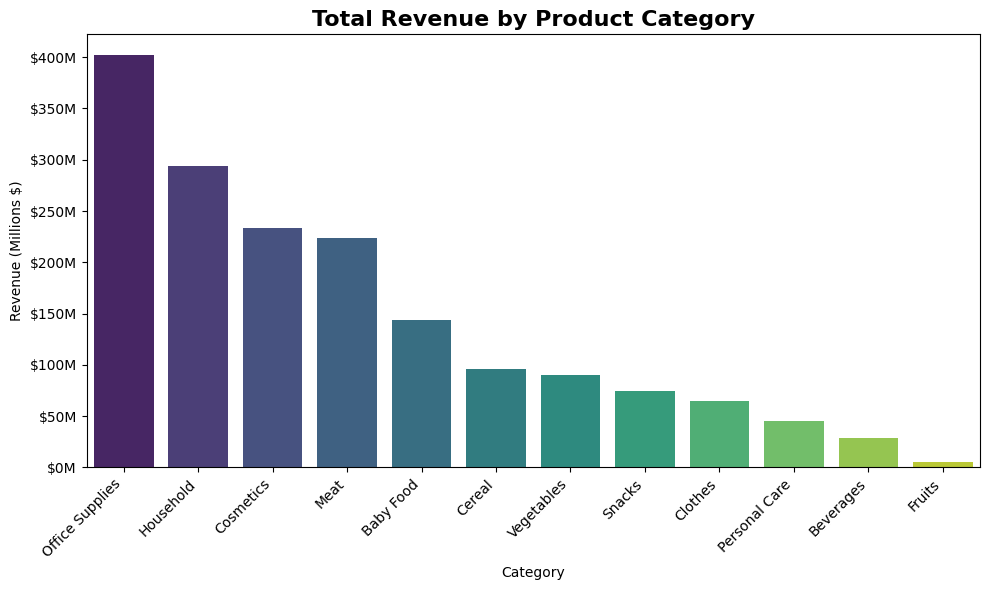

In [ ]:
# Total revenue by product category
revenue_by_category = df.groupby("product_category")["revenue"].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=revenue_by_category, x="product_category", y="revenue", palette="viridis", hue="product_category", legend=False)
# Y axis formatting in millions
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))
plt.title("Total Revenue by Product Category", fontsize=16, fontweight="bold")
plt.xlabel("Category")
plt.ylabel("Revenue (Millions $)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

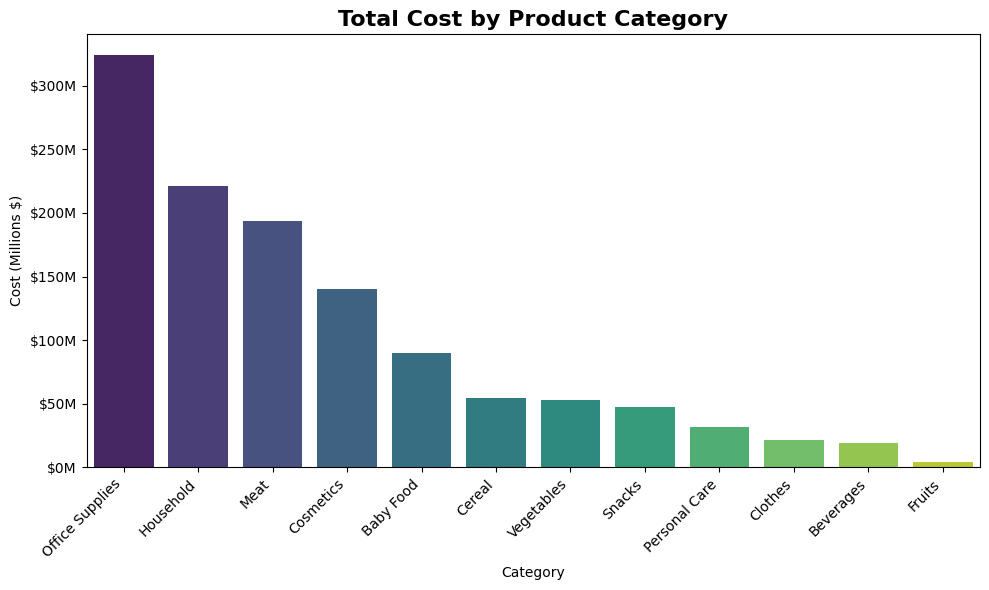

In [ ]:
# Total costs by product category
cost_by_category = df.groupby("product_category")["total_cost"].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=cost_by_category, x="product_category", y="total_cost", palette="viridis", hue="product_category", legend=False)
# Y axis formatting in millions
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))
plt.title("Total Cost by Product Category", fontsize=16, fontweight="bold")
plt.xlabel("Category")
plt.ylabel("Cost (Millions $)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

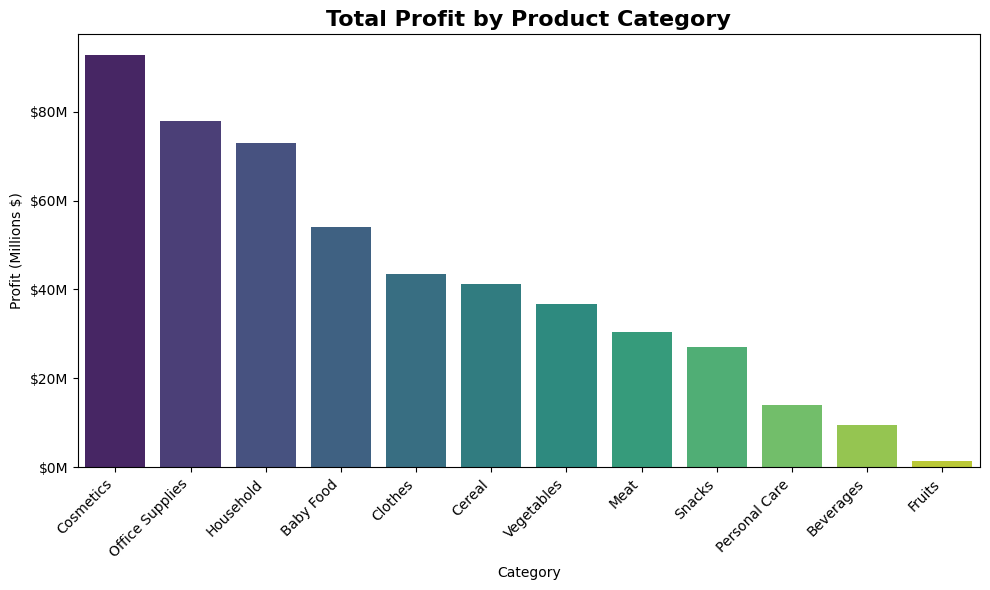

In [ ]:
# Total profit by product category
profit_by_category = df.groupby("product_category")["profit"].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=profit_by_category, x="product_category", y="profit", palette="viridis", hue="product_category", legend=False)
# Y axis formatting in millions
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))
plt.title("Total Profit by Product Category", fontsize=16, fontweight="bold")
plt.xlabel("Category")
plt.ylabel("Profit (Millions $)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Market Leader: Office Supplies generates the highest revenue and cost, while Cosmetics achieves the highest net profit.
### Key Contributors: Household, Cosmetics, and Meat continue to drive strong sales and revenue.
### Underperformers: Beverages and Fruits recorded the lowest figures across all metrics.

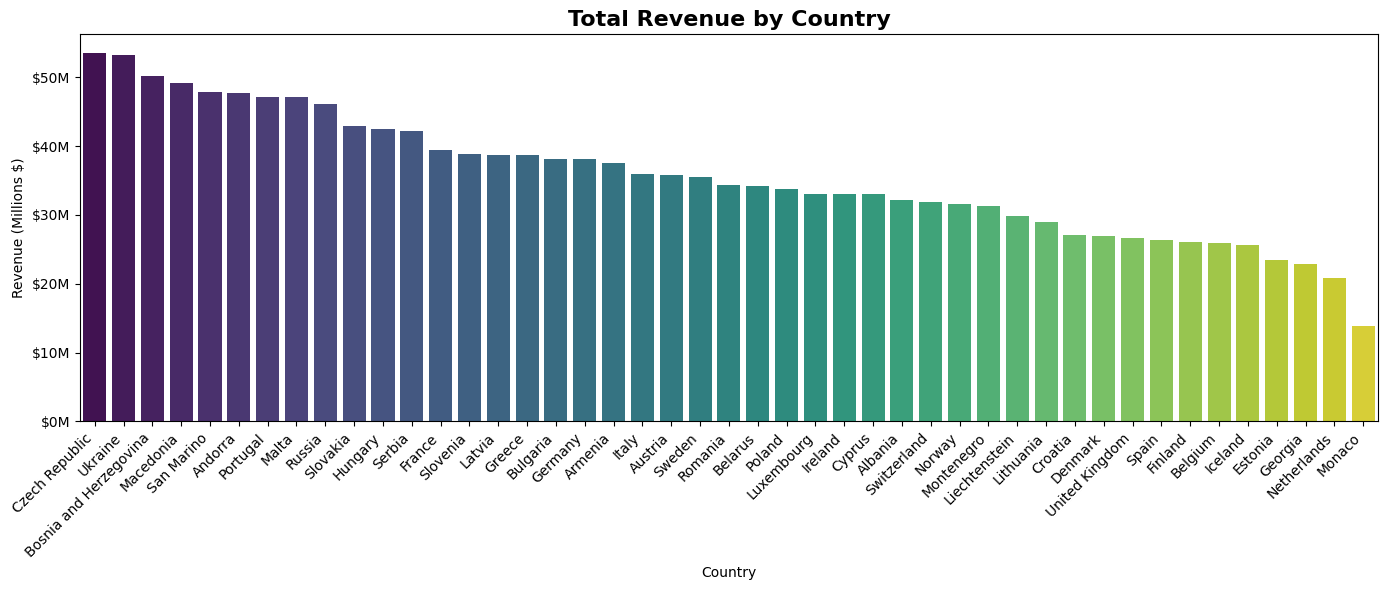

In [ ]:
# Total revenue by country
revenue_by_country = df.groupby("country")["revenue"].sum().sort_values(ascending=False).reset_index()
revenue_by_country = revenue_by_country[revenue_by_country["country"] != "Unknown"]

plt.figure(figsize=(14, 6))
sns.barplot(data=revenue_by_country, x="country", y="revenue", palette="viridis", hue="country", legend=False)
# Y axis formatting in millions
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))
plt.title("Total Revenue by Country", fontsize=16, fontweight="bold")
plt.xlabel("Country")
plt.ylabel("Revenue (Millions $)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

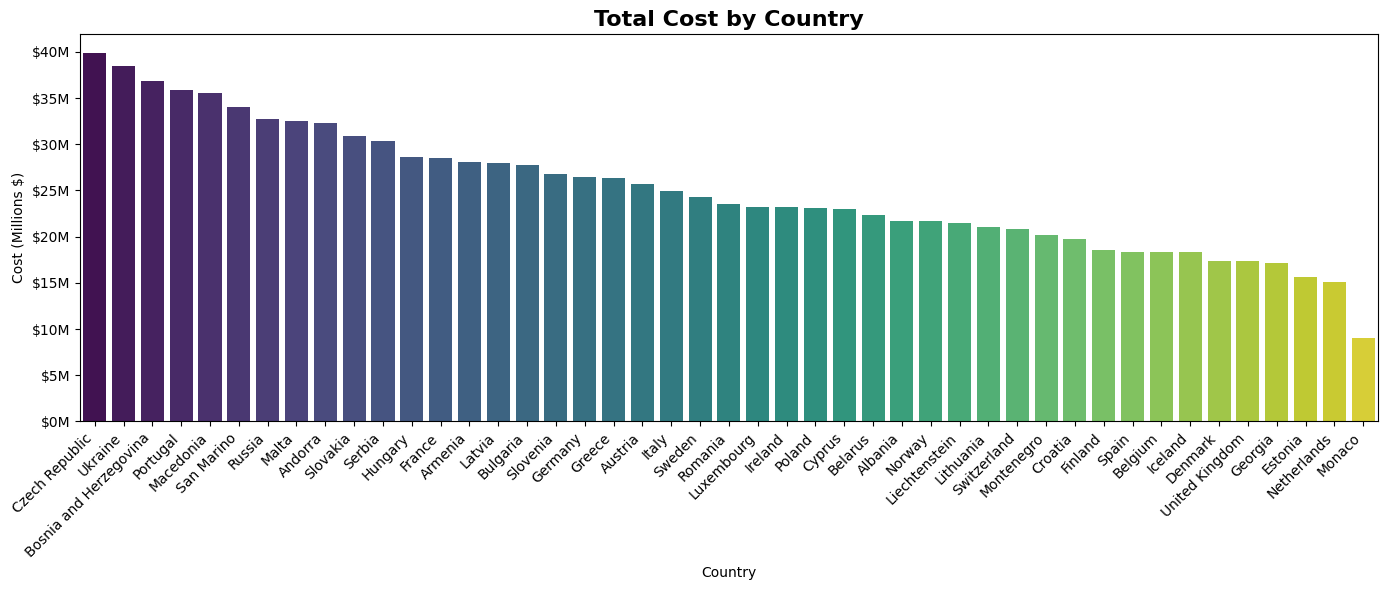

In [ ]:
# Total costs by country
cost_by_country = df.groupby("country")["total_cost"].sum().sort_values(ascending=False).reset_index()
cost_by_country = cost_by_country[cost_by_country["country"] != "Unknown"]

plt.figure(figsize=(14, 6))
sns.barplot(data=cost_by_country, x="country", y="total_cost", palette="viridis", hue="country", legend=False)
# Y axis formatting in millions
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))
plt.title("Total Cost by Country", fontsize=16, fontweight="bold")
plt.xlabel("Country")
plt.ylabel("Cost (Millions $)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

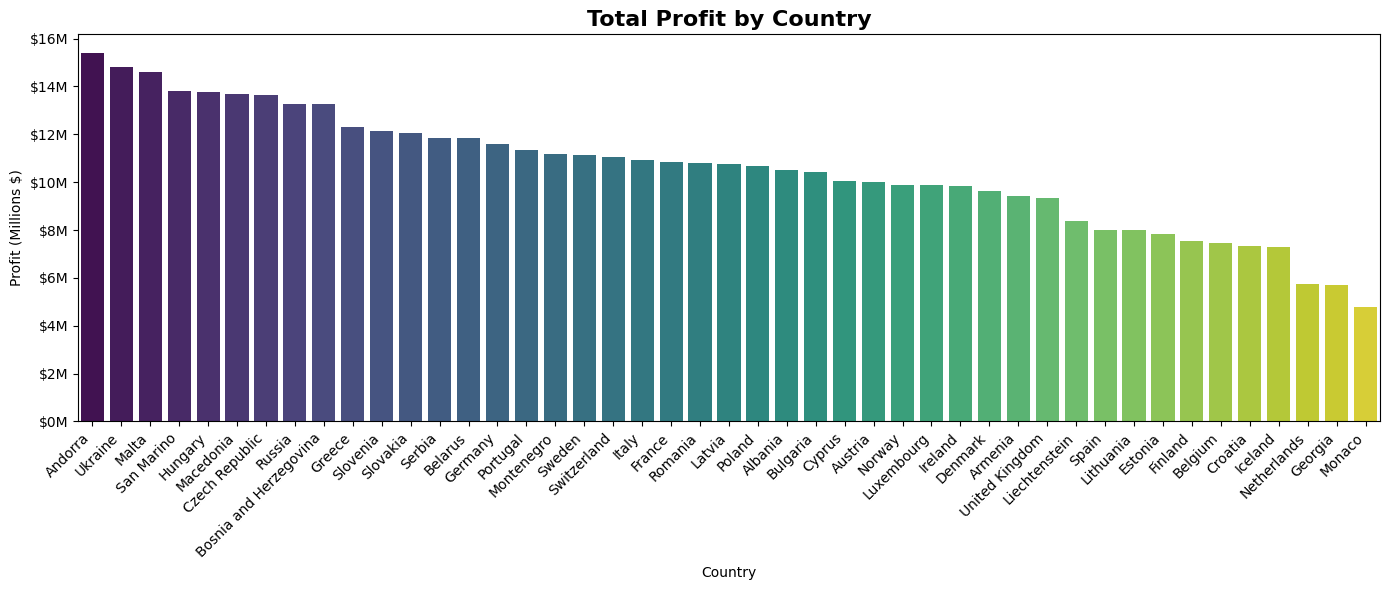

In [ ]:
# Total profit by country
profit_by_country = df.groupby("country")["profit"].sum().sort_values(ascending=False).reset_index()
profit_by_country = profit_by_country[profit_by_country["country"] != "Unknown"]

plt.figure(figsize=(14, 6))
sns.barplot(data=profit_by_country, x="country", y="profit", palette="viridis", hue="country", legend=False)
# Y axis formatting in millions
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))
plt.title("Total Profit by Country", fontsize=16, fontweight="bold")
plt.xlabel("Country")
plt.ylabel("Profit (Millions $)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Market Leader: Czech Republic generates the highest total revenue and cost. However, Andorra achieves the highest net profit, followed closely by Ukraine.
### Key Contributors: Malta, San Marino, and Hungary also demonstrate strong profitability.
### Underperformers: Monaco recorded the lowest figures across all metrics.

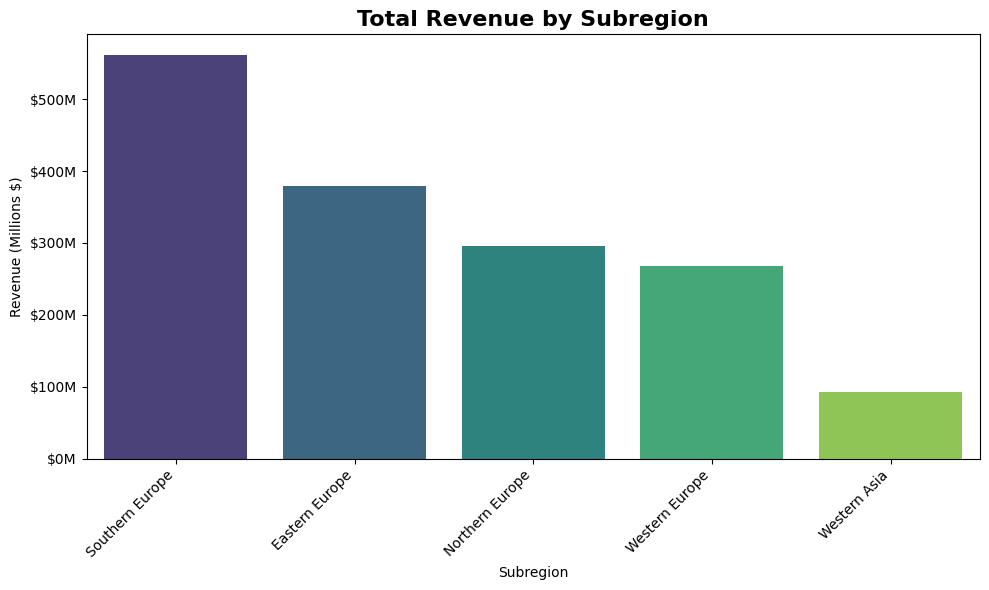

In [ ]:
# Total revenue by subregion
revenue_by_sub_region = df.groupby("sub_region")["revenue"].sum().sort_values(ascending=False).reset_index()
revenue_by_sub_region = revenue_by_sub_region[revenue_by_sub_region["sub_region"] != "Unknown"]

plt.figure(figsize=(10, 6))
sns.barplot(data=revenue_by_sub_region, x="sub_region", y="revenue", palette="viridis", hue="sub_region", legend=False)
# Y axis formatting in millions
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))
plt.title("Total Revenue by Subregion", fontsize=16, fontweight="bold")
plt.xlabel("Subregion")
plt.ylabel("Revenue (Millions $)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

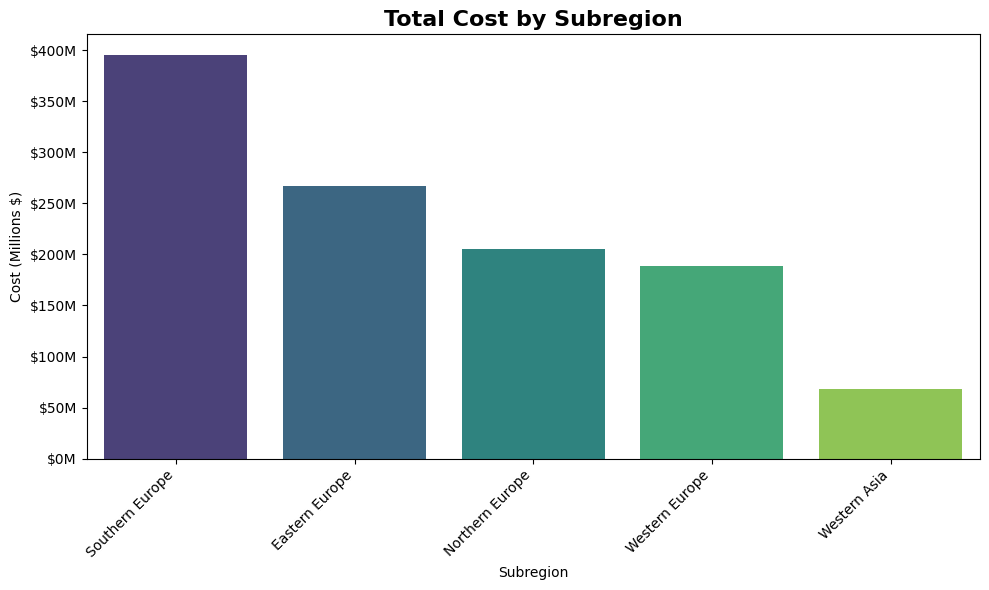

In [ ]:
# Total cost by subregion
cost_by_sub_region = df.groupby("sub_region")["total_cost"].sum().sort_values(ascending=False).reset_index()
cost_by_sub_region = cost_by_sub_region[cost_by_sub_region["sub_region"] != "Unknown"]

plt.figure(figsize=(10, 6))
sns.barplot(data=cost_by_sub_region, x="sub_region", y="total_cost", palette="viridis", hue="sub_region", legend=False)
# Y axis formatting in millions
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))
plt.title("Total Cost by Subregion", fontsize=16, fontweight="bold")
plt.xlabel("Subregion")
plt.ylabel("Cost (Millions $)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

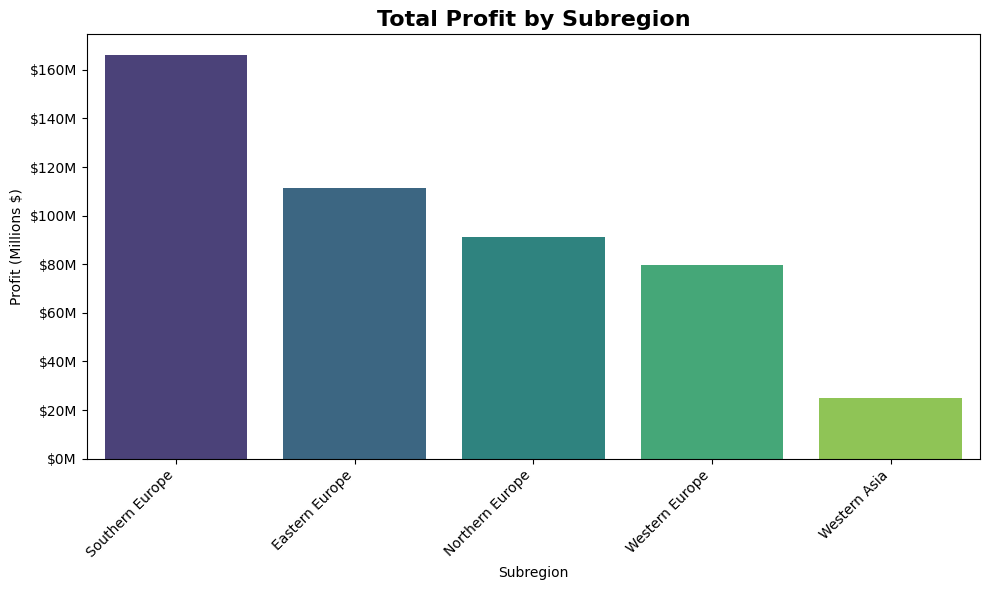

In [ ]:
# Total profit by subregion
profit_by_sub_region = df.groupby("sub_region")["profit"].sum().sort_values(ascending=False).reset_index()
profit_by_sub_region = profit_by_sub_region[profit_by_sub_region["sub_region"] != "Unknown"]

plt.figure(figsize=(10, 6))
sns.barplot(data=profit_by_sub_region, x="sub_region", y="profit", palette="viridis", hue="sub_region", legend=False)
# Y axis formatting in millions
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))
plt.title("Total Profit by Subregion", fontsize=16, fontweight="bold")
plt.xlabel("Subregion")
plt.ylabel("Profit (Millions $)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Southern Europe stands out as the leading region in Europe, contributing the majority of overall revenue and profits. In contrast, Asia falls behind, generating the least revenue.

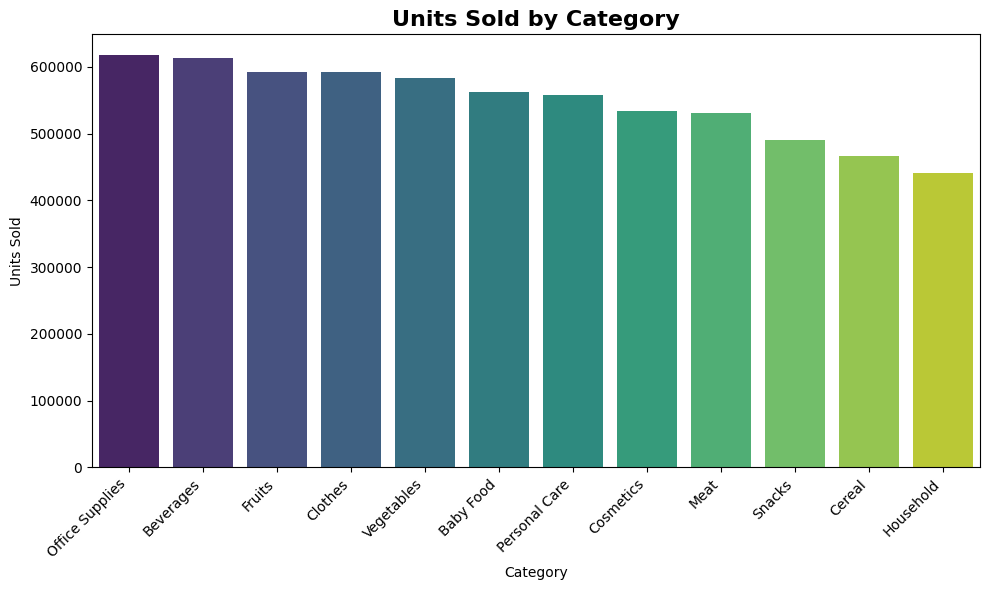

In [ ]:
# Product category popularity
product_popularity = df.groupby("product_category")["units_sold"].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=product_popularity, x="product_category", y="units_sold", palette="viridis", hue="product_category", legend=False)
plt.title("Units Sold by Category", fontsize=16, fontweight="bold")
plt.xlabel("Category")
plt.ylabel("Units Sold")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Office Supplies dominates in sales volume and total profit.
### Beverages and Fruits rank in the top 3 for units sold but generate the lowest revenue and profit.
### Household has the lowest sales volume but ranks among the top contributors for net profit.

### **Order-to-shipment time analysis**

In [ ]:
df['shipping_time'] = (df['ship_date'] - df['order_date']).dt.days
df.head()

,order_id,order_date,ship_date,order_priority,country_code,sales_channel,units_sold,unit_price,unit_cost,product_category,country,region,sub_region,revenue,total_cost,profit,shipping_time
0,100640618,2014-10-08,2014-10-18,M,NOR,Online,650,205.70,117.11,Cereal,Norway,Europe,Northern Europe,133705.00,76121.50,57583.50,10
1,100983083,2016-08-11,2016-08-11,C,SRB,Offline,1993,205.70,117.11,Cereal,Serbia,Europe,Southern Europe,409960.10,233400.23,176559.87,0
2,101025998,2014-07-18,2014-08-11,M,Unknown,Online,4693,668.27,502.54,Household,Unknown,Unknown,Unknown,3136191.11,2358420.22,777770.89,24
3,102230632,2017-05-13,2017-06-13,L,MNE,Online,1171,109.28,35.84,Clothes,Montenegro,Europe,Southern Europe,127966.88,41968.64,85998.24,31
4,103435266,2012-08-11,2012-09-18,H,SRB,Offline,7648,47.45,31.79,Beverages,Serbia,Europe,Southern Europe,362897.60,243129.92,119767.68,38


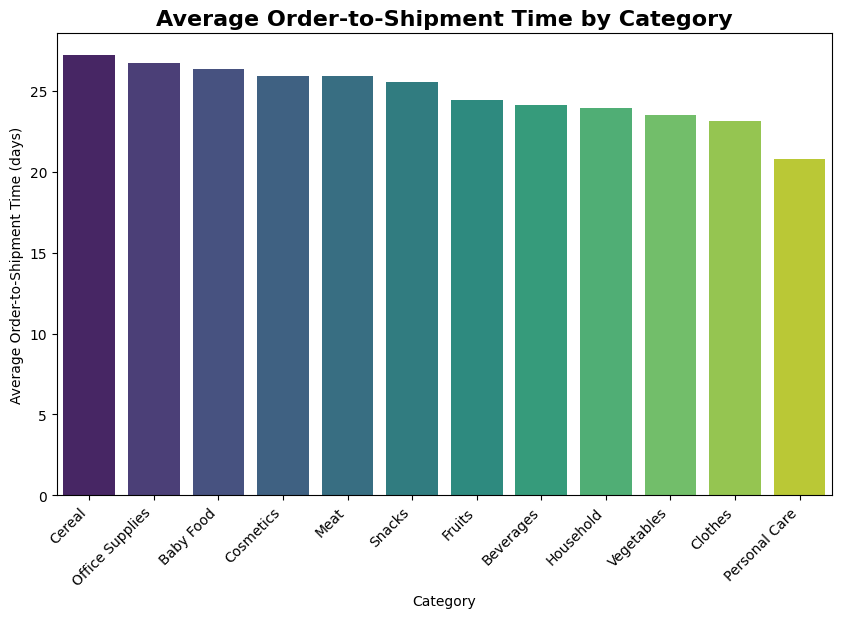

In [ ]:
# Visualizing the average order-to-shipment time by product category
shipping_time_by_category = df.groupby("product_category")["shipping_time"].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10,6))
sns.barplot(data=shipping_time_by_category, x="product_category", y="shipping_time", palette="viridis", hue="product_category", legend=False)
plt.title("Average Order-to-Shipment Time by Category", fontsize=16, fontweight="bold")
plt.xlabel("Category")
plt.ylabel("Average Order-to-Shipment Time (days)")
plt.xticks(rotation=45, ha="right")
plt.show()

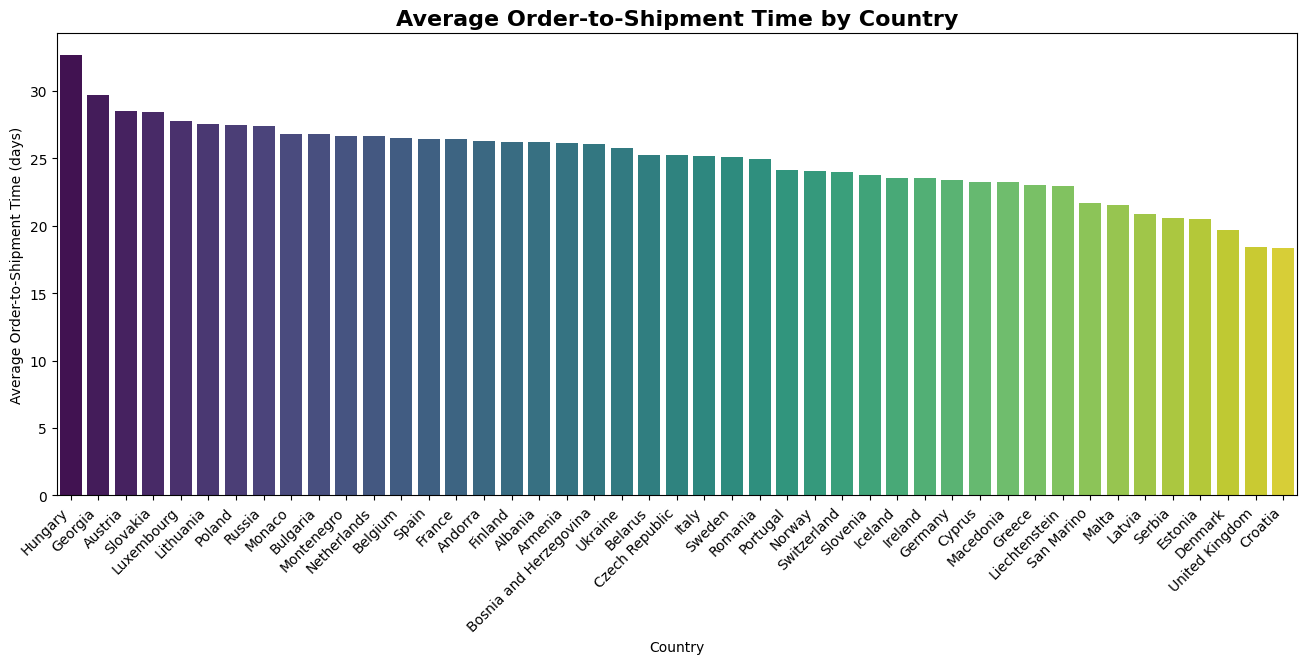

In [ ]:
# Visualizing the average order-to-shipment time by country
shipping_time_by_country = df.groupby("country")["shipping_time"].mean().sort_values(ascending=False).reset_index()
shipping_time_by_country = shipping_time_by_country[shipping_time_by_country["country"] != "Unknown"]


plt.figure(figsize=(16,6))
sns.barplot(data=shipping_time_by_country, x="country", y="shipping_time", palette="viridis", hue="country", legend=False)
plt.title("Average Order-to-Shipment Time by Country", fontsize=16, fontweight="bold")
plt.xlabel("Country")
plt.ylabel("Average Order-to-Shipment Time (days)")
plt.xticks(rotation=45, ha="right")
plt.show()

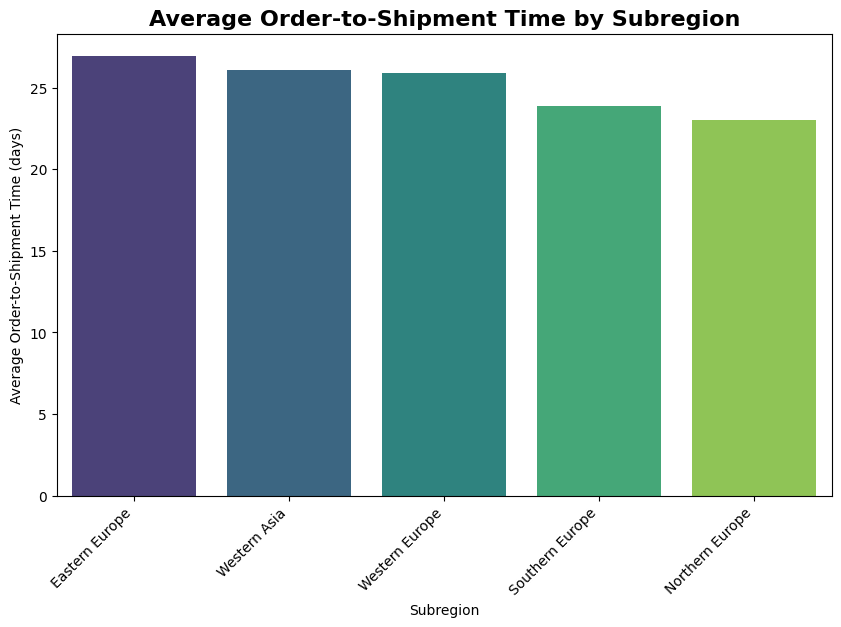

In [ ]:
# Visualizing the average order-to-shipment time by subregion
shipping_time_by_sub_region = df.groupby("sub_region")["shipping_time"].mean().sort_values(ascending=False).reset_index()
shipping_time_by_sub_region = shipping_time_by_sub_region[shipping_time_by_sub_region["sub_region"] != "Unknown"]

plt.figure(figsize=(10,6))
sns.barplot(data=shipping_time_by_sub_region, x="sub_region", y="shipping_time", palette="viridis", hue="sub_region", legend=False)
plt.title("Average Order-to-Shipment Time by Subregion", fontsize=16, fontweight="bold")
plt.xlabel("Subregion")
plt.ylabel("Average Order-to-Shipment Time (days)")
plt.xticks(rotation=45, ha="right")
plt.show()

### Personal Care is the best in terms of logistics, with the quickest average order-to-shipment time. In Northern Europe, order-to-shipment time is especially fast and efficient.
### However, Cereal and Office Supplies face the longest processing delays. Among countries, Hungary has the biggest delays order-to-shipment times, while Croatia and the United Kingdom have the fastest.

### **Analysis of profit depending on order-to-shipment time**

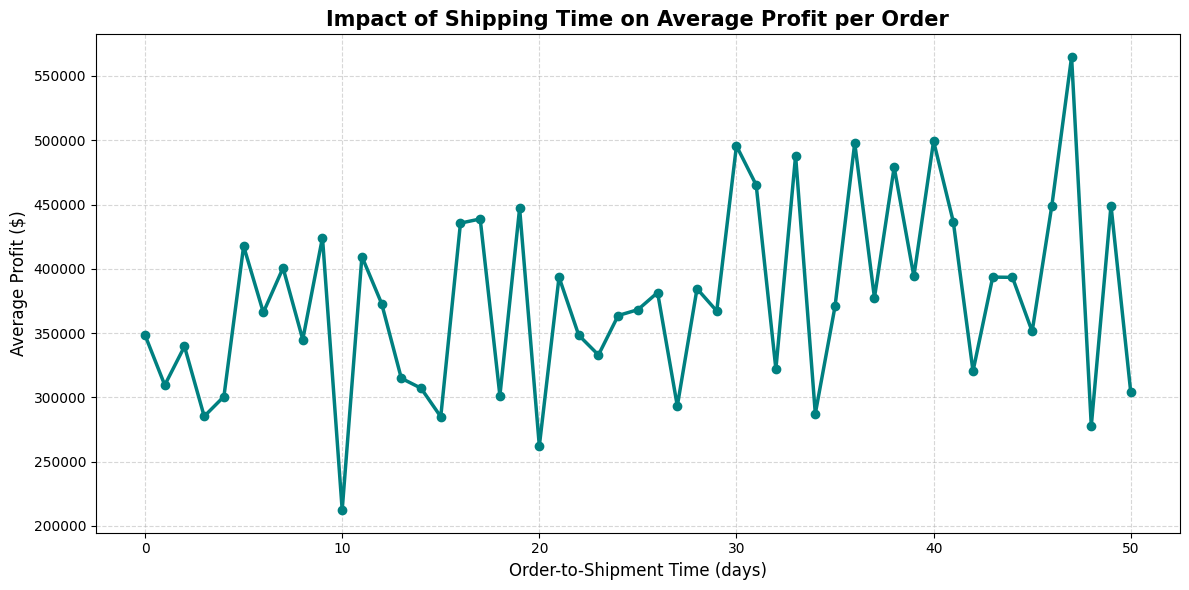

In [ ]:
# Visualizing the impact of average order-to-shipment time on profit
profit_trend = df.groupby("shipping_time")["profit"].mean().reset_index()

plt.figure(figsize=(12, 6))
plt.plot(profit_trend["shipping_time"], profit_trend["profit"], marker='o', color='teal', linewidth=2.5, markersize=6)
plt.title("Impact of Shipping Time on Average Profit per Order", fontsize=15, fontweight="bold")
plt.xlabel("Order-to-Shipment Time (days)", fontsize=12)
plt.ylabel("Average Profit ($)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### There is no structural correlation between the order-to-shipment duration and the transaction profitability.

### **Analysis of sales over time**

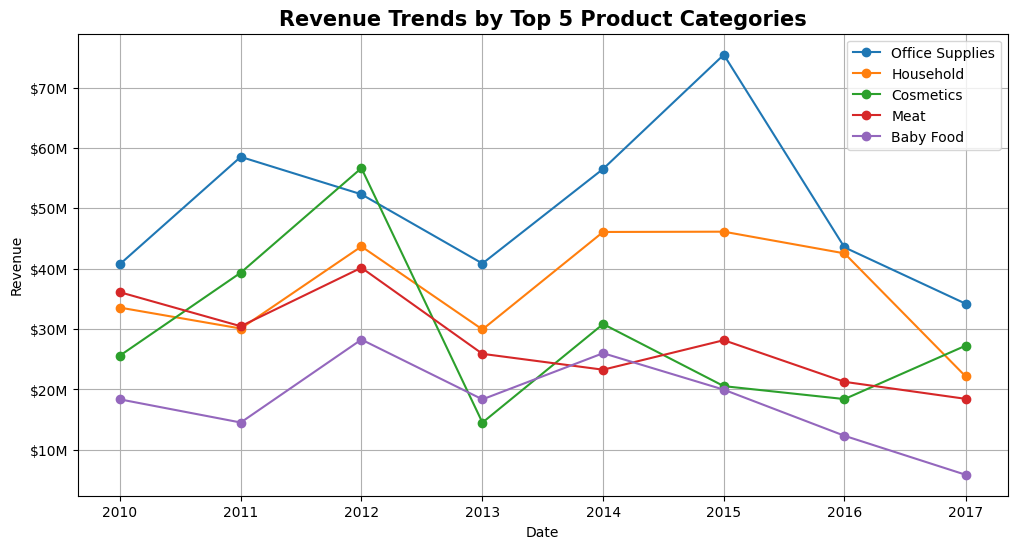

In [ ]:
# Visualizing revenue over time for the top 5 product categories
df["year"] = df["order_date"].dt.to_period("Y").dt.to_timestamp()
time_series_data = (df.groupby(["product_category", "year"])["revenue"].sum().reset_index())
time_series_data = time_series_data.sort_values("year")

product_categories = df.groupby("product_category")["revenue"].sum().sort_values(ascending=False).head(5).index

plt.figure(figsize=(12,6))
for category in product_categories:
  category_data = time_series_data[time_series_data["product_category"] == category]
  plt.plot(category_data["year"], category_data["revenue"], label=category, marker="o")

# Y axis formatting in millions
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.title("Revenue Trends by Top 5 Product Categories", fontsize=15, fontweight="bold")
plt.legend()
plt.grid(True)
plt.show()

### All five main product lines move up and down together, showing a shared trend. There is a significant joint drop in 2013, followed by a strong peak in 2015, after which all items began to decline again.

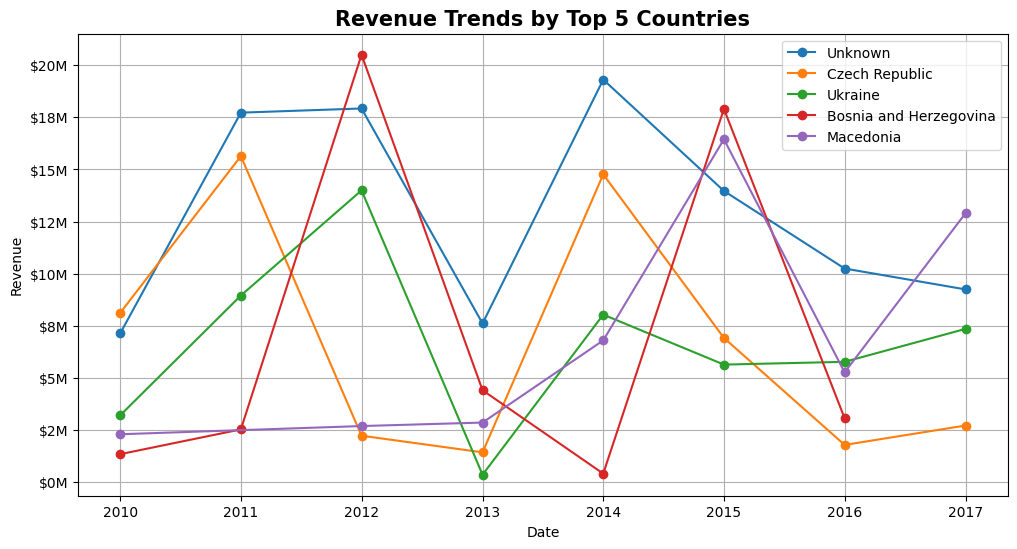

In [ ]:
# Visualizing revenue over time for the top 5 countries
time_series_data = (df.groupby(["country", "year"])["revenue"].sum().reset_index())
time_series_data = time_series_data.sort_values("year")

countries = countries[countries != "Unknown"]
countries = df.groupby("country")["revenue"].sum().sort_values(ascending=False).head(5).index

plt.figure(figsize=(12,6))
for country in countries:
  country_data = time_series_data[time_series_data["country"] == country]
  plt.plot(country_data["year"], country_data["revenue"], label=country, marker="o")

# Y axis formatting in millions
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.title("Revenue Trends by Top 5 Countries", fontsize=15, fontweight="bold")
plt.legend()
plt.grid(True)
plt.show()

### The top countries show highly volatile, individual trends with huge spikes and drops year-over-year. However, almost all markets experienced a sharp, synchronized revenue crash in 2013 before attempting temporary recoveries.

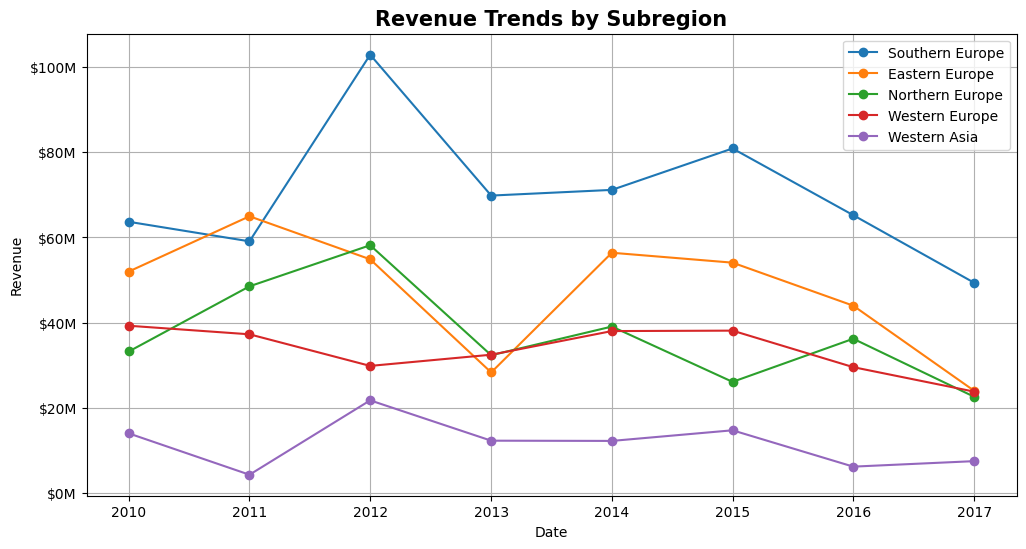

In [ ]:
# Visualizing revenue over time by subregion
time_series_data = (df.groupby(["sub_region", "year"])["revenue"].sum().reset_index())
time_series_data = time_series_data.sort_values("year")

all_sub_regions = df.groupby("sub_region")["revenue"].sum().sort_values(ascending=False).index
sub_regions = all_sub_regions[all_sub_regions != "Unknown"]

plt.figure(figsize=(12,6))
for sub_region in sub_regions:
  sub_region_data = time_series_data[time_series_data["sub_region"] == sub_region]
  plt.plot(sub_region_data["year"], sub_region_data["revenue"], label=sub_region, marker="o")

# Y axis formatting in millions
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.title("Revenue Trends by Subregion", fontsize=15, fontweight="bold")
plt.legend()
plt.grid(True)
plt.show()

### Southern Europe and Eastern Europe clearly dominate global revenues, but they both follow the exact same big pattern: a major drop in 2013, a solid peak between 2014–2015, and a steady decline afterward.

### **Analysis of product sales by day of the week and season**

/tmp/ipykernel_4864/3299048891.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sales_by_day = df.groupby("day")["revenue"].sum()


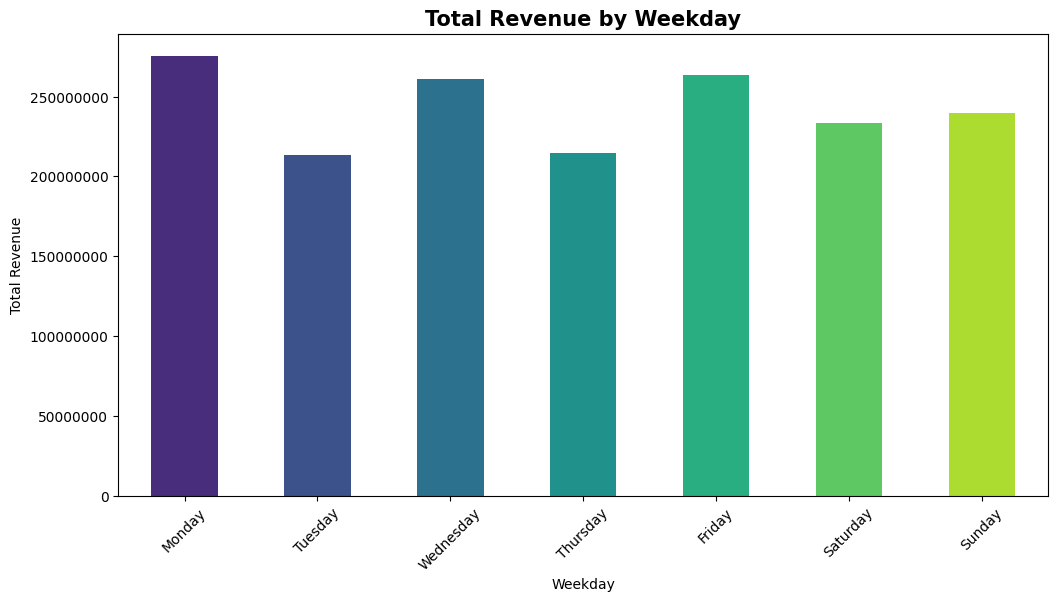

In [ ]:
# Visualizing total revenue by weekday
df['day'] = df['order_date'].dt.day_name()

weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
colors = sns.color_palette("viridis", n_colors=len(weekday_order))

df["day"] = pd.Categorical(df["day"], categories=weekday_order, ordered=True)

sales_by_day = df.groupby("day")["revenue"].sum()

sales_by_day.plot(kind="bar", color=colors, figsize=(12,6))
plt.title("Total Revenue by Weekday", fontsize=15, fontweight="bold")
plt.xlabel("Weekday")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.ticklabel_format(style='plain', axis='y')
plt.show()

### Total revenue is distributed almost completely evenly across all days of the week. There is no major weekend slump or weekday peak, meaning that order generation operates continuously.

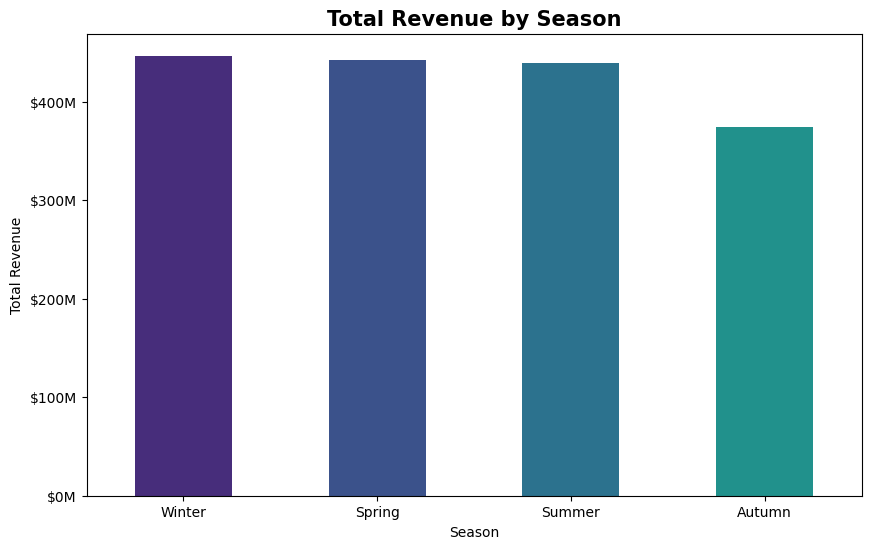

In [ ]:
# Visualizing total revenue by season
season_map = {
    12: "Winter", 1: "Winter", 2: "Winter",
    3: "Spring", 4: "Spring", 5: "Spring",
    6: "Summer", 7: "Summer", 8: "Summer",
    9: "Autumn", 10: "Autumn", 11: "Autumn"}

colors = sns.color_palette("viridis", n_colors=len(weekday_order))

df["season"] = df["order_date"].dt.month.map(season_map)

# Y axis formatting in millions
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))
sales_by_season = df.groupby("season")["revenue"].sum().sort_values(ascending=False)
sales_by_season.plot(kind="bar", color=colors, figsize=(10,6))
plt.title("Total Revenue by Season", fontsize=15, fontweight="bold")
plt.xlabel("Season")
plt.ylabel("Total Revenue")
plt.xticks(rotation=0)
plt.show()

### The business shows no traditional holiday or weather-based seasonality, as Winter, Spring, and Summer all bring in an identical. The only visible outlier is Autumn, which experiences a slight drop, suggesting a minor seasonal softening in sales during the third quarter.

# **Business Summary**

## **Product Categories**
### Office Supplies leads in sales volume and total revenue, but Cosmetics achieves the highest net profit margin. Beverages and Fruits are underperformers — high unit sales but minimal revenue and profit contribution.

## **Geography**
### Czech Republic leads in total revenue and costs. Andorra and Ukraine deliver the highest net profit. At the subregional level, Southern Europe dominates both revenue and profitability.
## **Logistics**
### No correlation found between order-to-shipment time and profit. Personal Care is the fastest category for delivery. Longest delays observed in Hungary; fastest processing in Croatia and the UK.

## **Revenue Trends Over Time**
### A sharp synchronized drop across all categories and regions in 2013, a strong peak in 2015, followed by steady decline. The fact that all segments move together suggests an external market driver rather than internal operational issues.

## **Seasonality**
### Virtually absent — revenue is evenly distributed across all days of the week and seasons. A minor dip in Autumn is the only visible deviation.